In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

In [42]:
PROJECT_ROOT = Path.cwd().parents[1]
CSV_PATH = PROJECT_ROOT / Path("./data/ic50_median_threshold_raw.csv").resolve()
print(CSV_PATH)

E:\Study\projects\coursework_classic_ml\data\ic50_median_threshold_raw.csv


In [43]:
df = pd.read_csv(CSV_PATH)
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,NumRadicalElectrons,MaxPartialCharge,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,median_threshold
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,0,0.038844,...,0,0,0,0,0,0,0,3,0,0
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,0,0.012887,...,0,0,0,0,0,0,0,3,0,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,0,0.094802,...,0,0,0,0,0,0,0,3,0,1
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,0,0.038844,...,0,0,0,0,0,0,0,4,0,0
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,0,0.062897,...,0,0,0,0,0,0,0,0,0,1


<Axes: xlabel='median_threshold', ylabel='Count'>

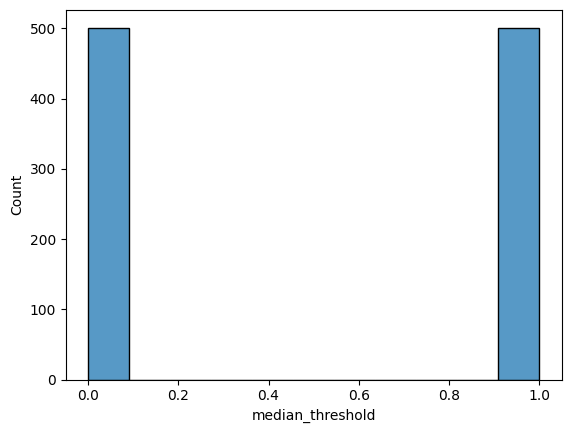

In [44]:
sns.histplot(df['median_threshold'])

In [45]:
X_ic50 = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y_ic50 = df['median_threshold']
X_train, X_test, y_train, y_test = train_test_split(X_ic50, y_ic50, test_size=0.2, random_state=42, stratify=y_ic50)
pipeline = Pipeline([('scaler', StandardScaler()),
                      ('model', LogisticRegression())])
pipeline.fit(X_train, y_train)
pred_train = pipeline.predict(X_train)
pred_test = pipeline.predict(X_test)

In [46]:
print(confusion_matrix(y_train, pred_train))

[[400   0]
 [  0 400]]


In [47]:
print(confusion_matrix(y_test, pred_test))

[[101   0]
 [  0 100]]


In [48]:
print(f1_score(y_test, pred_test))

1.0
